# 🦋 Parvaneh: independent synthetic examples

This notebook exercises the public package without external executables, book data, or downloaded files. Every array is generated deterministically in memory.

In [1]:
from pathlib import Path
import sys, time
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC = ROOT / 'src'
if (SRC / 'parvaneh').is_dir() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from parvaneh import (
    SAKURA, SAKURA_DIVERGING, flynn_unwrap, goldstein_unwrap,
    make_synthetic, mask_cut_unwrap, network_flow_unwrap, phase_residues,
    quality_guided_unwrap, reliability_unwrap, rmse_aligned,
    unwrap, unwrap_lp,
)

## 1. Generate an original wrapped-phase experiment

The generator combines a phase ramp and localized smooth structures, adds spatially varying Gaussian noise, wraps the observation into $[-\pi,\pi)$, and returns a reliability map.

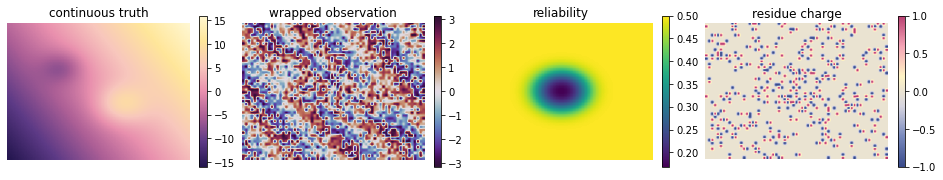

In [2]:
truth, wrapped, quality = make_synthetic((48, 64), noise=1.20, seed=19)
residues = phase_residues(wrapped)

fig, axes = plt.subplots(1, 4, figsize=(13, 3), constrained_layout=True)
items = [(truth, 'continuous truth', SAKURA),
         (wrapped, 'wrapped observation', 'twilight_shifted'),
         (quality, 'reliability', 'viridis'),
         (residues, 'residue charge', SAKURA_DIVERGING)]
for axis, (image, title, cmap) in zip(axes, items):
    artist = axis.imshow(image, origin='lower', cmap=cmap)
    axis.set_title(title); axis.axis('off')
    fig.colorbar(artist, ax=axis, shrink=.72)
plt.show()

## 2. Run independent algorithm families

The comparison uses identical input and offset-aligned RMSE after removing a constant offset, which is the only freedom a wrapped observation leaves. Numba compilation is warmed before timing, and the reliability rating of section 1 is reused as the weight map.

The noise level is deliberately high. Path-following and cut-based solvers break down once the residues are dense, while global solvers such as robust minimum norm and reliability sorting degrade more gracefully; showing that spread is the point of the experiment.

In [3]:
quality_guided_unwrap(wrapped[:16, :20], 'min_gradient', backend='numba')
methods = {
    'Goldstein': lambda: goldstein_unwrap(wrapped),
    'quality guided': lambda: quality_guided_unwrap(wrapped, 'min_gradient', backend='numba'),
    'reliability': lambda: reliability_unwrap(wrapped, quality, backend='numba'),
    'mask cuts': lambda: mask_cut_unwrap(wrapped, quality > 0.2),
    'weighted L2': lambda: unwrap(wrapped, quality, backend='numba', workers=-1),
    'min-cost flow': lambda: network_flow_unwrap(wrapped, quality),
    'robust L1.2': lambda: unwrap_lp(wrapped, p=1.2, outer_iter=6),
    'Flynn': lambda: flynn_unwrap(wrapped),
}
results, metrics = {}, []
for name, solve in methods.items():
    start = time.perf_counter(); result = solve(); elapsed = time.perf_counter() - start
    result = result + np.mean(truth - result)
    results[name] = result
    metrics.append((name, rmse_aligned(result, truth), elapsed))

for name, error, elapsed in metrics:
    print(f'{name:16s} RMSE={error:.5f} rad  time={elapsed:.4f} s')

Goldstein        RMSE=7.17996 rad  time=0.0734 s
quality guided   RMSE=3.62069 rad  time=0.0006 s
reliability      RMSE=1.95684 rad  time=0.0041 s
mask cuts        RMSE=8.01753 rad  time=0.2396 s
weighted L2      RMSE=4.16225 rad  time=0.0112 s
min-cost flow    RMSE=1.48173 rad  time=0.5712 s
robust L1.2      RMSE=1.88633 rad  time=0.1106 s
Flynn            RMSE=1.50381 rad  time=0.3126 s


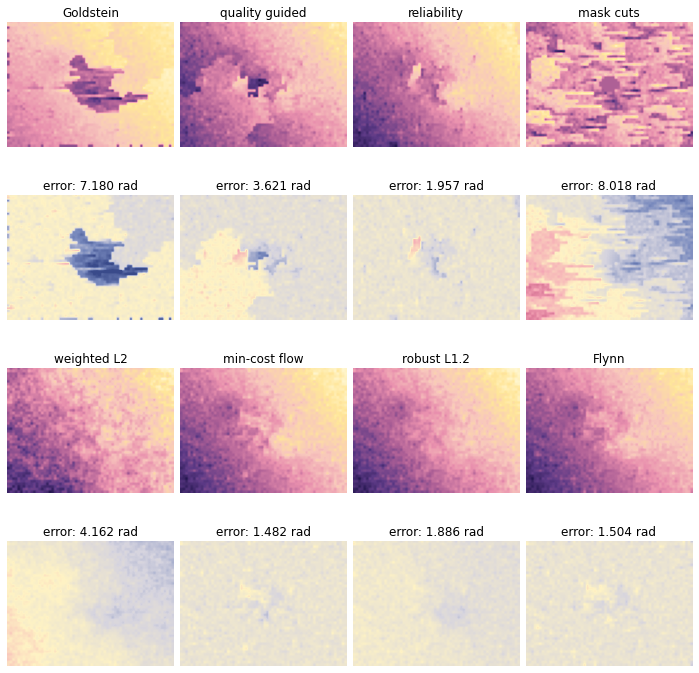

In [4]:
per_row = 4
blocks = int(np.ceil(len(results) / per_row))
fig, axes = plt.subplots(2 * blocks, per_row, figsize=(2.4 * per_row, 4.8 * blocks), constrained_layout=True)
limit = max(np.percentile(np.abs(value - truth), 99) for value in results.values())
for column, (name, result) in enumerate(results.items()):
    block, offset = divmod(column, per_row)
    reconstruction, error = axes[2 * block, offset], axes[2 * block + 1, offset]
    reconstruction.imshow(result, origin='lower', cmap=SAKURA)
    reconstruction.set_title(name)
    error.imshow(result - truth, origin='lower', cmap=SAKURA_DIVERGING, vmin=-limit, vmax=limit)
    error.set_title(f'error: {rmse_aligned(result, truth):.3f} rad')
    reconstruction.axis('off'); error.axis('off')
axes[0, 0].set_ylabel('reconstruction'); axes[1, 0].set_ylabel('error')
for unused in axes.flat[2 * len(results):]:
    unused.axis('off')
plt.show()

## 3. Inside the minimum-cost flow solver

The flow solver is the one family in the table whose answer can be checked against the problem it claims to solve, so it is worth opening up. It places one node in every $2\times2$ cell of the phase grid, one arc on every pixel difference, and one ground node that absorbs whatever is left over. Conservation of flow at a cell says that the four corrected steps around that cell add up to zero, and the integer flow on an arc is the number of whole turns of that pixel difference. Minimising the total weighted jump $\sum_e w_e |k_e|$ over those constraints is a linear program on a network, so an integer optimum exists and the augmenting-path solver finds it.

The record below reports what the search cost. `residues` is the residue charge of the input, counting both signs, so one dipole contributes two units; `nodes` and `edges` describe the network; and `augmentations` counts the successive shortest paths, each of which repairs one unit of imbalance. A clean scene arrives already balanced and needs none of them, which is why the running time tracks the residue count rather than the pixel count (Costantini 1998; derivation in [`../docs/mathematics.md`](../docs/mathematics.md), section 13).


One number in that record is worth a warning, because it is the first thing a reader checks and it looks wrong by one. The charge of a closed array need not cancel: like the winding of the wrapped gradient around the whole image, it sums to the net number of whole turns the measured gradient accumulates along the outer boundary, and that leftover is what the ground node absorbs. Here the input carries $492$ units of charge of both signs --- $247$ positive and $245$ negative --- so `augmentations` is $247$ and not the $246$ that "half of $492$" would suggest, and the remaining $2$ units of imbalance are what `ground_imbalance` reports. The next cell checks that bookkeeping: $2 \times 247 - 492 = 2$. On the synthetic sweep in `benchmarks/benchmark_mcf.py` the boundary happens to close, so there two augmentations do retire two units of charge.


In [5]:
flow_result, flow_info = network_flow_unwrap(wrapped, quality, return_info=True)
print('residue charge of the input   : %d' % flow_info.residues)
print('network nodes (2x2 cells)     : %d' % flow_info.nodes)
print('network arcs (pixel edges)    : %d' % flow_info.edges)
print('flow augmentations performed  : %d' % flow_info.augmentations)
print('largest integer jump placed   : %d turn(s)' % flow_info.max_jump)
print('charge absorbed by the ground : %d' % flow_info.ground_imbalance)
print('check 2*augmentations - charge: %d' % (2 * flow_info.augmentations - flow_info.residues))
print('aligned RMSE                  : %.4f rad' % rmse_aligned(flow_result, truth))
print('phase congruence with input   : %.1e rad' % np.abs(np.angle(np.exp(1j * (flow_result - wrapped)))).max())

residue charge of the input   : 492
network nodes (2x2 cells)     : 2962
network arcs (pixel edges)    : 6032
flow augmentations performed  : 247
largest integer jump placed   : 1 turn(s)
charge absorbed by the ground : 2
check 2*augmentations - charge: 2
aligned RMSE                  : 1.4817 rad
phase congruence with input   : 2.3e-14 rad


## 4. Reproducibility checks

A valid public example should be deterministic, finite, shape preserving, and phase-congruent where required. The package test suite adds backend-equivalence, topology, input-validation, and raw-I/O tests, and it re-solves the flow network above with a linear program to confirm that the published cost is the true optimum.

```bash
pytest -q
python benchmarks/benchmark_backends.py
python benchmarks/benchmark_path_following.py
python benchmarks/benchmark_mcf.py
```